# 过拟合和欠拟合

In [1]:
import torch
import torch.nn as nn
import math
import numpy as np
from d2l import torch as d2l

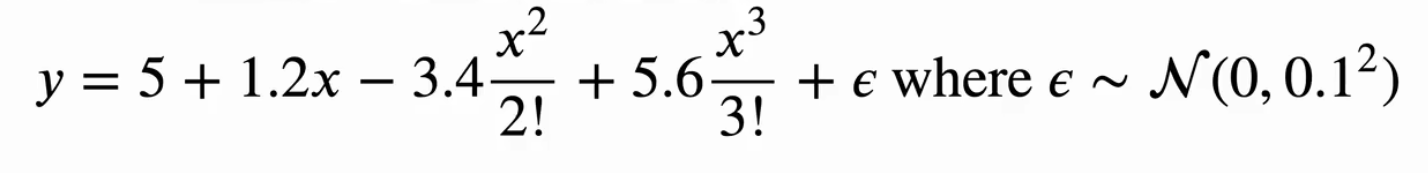

In [ ]:
max_degree = 20  # Maximum degree of the polynomial
n_train, n_test = 100, 100  # Number of training and test examples
true_w = np.zeros(max_degree)  # True weights
true_w[0:4] = np.array([5, 1.2, -3.4, 5.6])  # Set the first four weights
features = np.random.normal(size=(n_train + n_test, 1))  # Generate features
np.random.shuffle(features)  # Shuffle the features
poly_features = np.power(features, np.arange(max_degree))  # Generate polynomial features
for i in range(max_degree):
    poly_features[:, i] /= math.gamma(i + 1)  # Scale features by factorial
labels = (poly_features @ true_w) + np.random.normal(scale=0.1, size=(n_train + n_test,))  # Generate labels with noise

In [4]:
true_w, poly_features, labels = [torch.tensor(x, dtype=torch.float32) for x in (true_w, poly_features, labels)]
features[:2], poly_features[:2, :], labels[:2]

(array([[0.38761363],
        [2.18653562]]),
 tensor([[1.0000e+00, 3.8761e-01, 7.5122e-02, 9.7061e-03, 9.4056e-04, 7.2915e-05,
          4.7104e-06, 2.6083e-07, 1.2638e-08, 5.4429e-10, 2.1097e-11, 7.4342e-13,
          2.4013e-14, 7.1599e-16, 1.9823e-17, 5.1225e-19, 1.2410e-20, 2.8295e-22,
          6.0931e-24, 1.2430e-25],
         [1.0000e+00, 2.1865e+00, 2.3905e+00, 1.7423e+00, 9.5239e-01, 4.1649e-01,
          1.5178e-01, 4.7410e-02, 1.2958e-02, 3.1481e-03, 6.8834e-04, 1.3683e-04,
          2.4931e-05, 4.1933e-06, 6.5491e-07, 9.5466e-08, 1.3046e-08, 1.6780e-09,
          2.0383e-10, 2.3457e-11]]),
 tensor([5.1710, 9.2121]))

In [5]:
def evaluate_loss(net, data_iter, loss):  #@save
    """Evaluate the loss of a model on the given dataset."""
    metric = d2l.Accumulator(2)  # Sum of losses, no. of examples
    for X, y in data_iter:
        out = net(X)
        y = y.reshape(out.shape)
        l = loss(out, y)
        metric.add(l.sum(), l.numel())
    return metric[0] / metric[1]

In [10]:
import tools
def train(train_features, test_features, train_labels, test_labels,
          num_epochs=400):
    """Train a model on training set and evaluate on test set."""
    loss = nn.MSELoss(reduction='none')
    input_shape = train_features.shape[-1]
    net = nn.Sequential(nn.Linear(input_shape, 1,bias=False),)
    batch_size = min(10, train_labels.shape[0])
    train_iter = d2l.load_array((train_features, train_labels.reshape(-1, 1)),
                                batch_size)
    test_iter = d2l.load_array((test_features, test_labels.reshape(-1, 1)),
                               batch_size, is_train=False)
    trainer = torch.optim.SGD(net.parameters(), lr=0.01)
    animator = d2l.Animator(xlabel='epoch', ylabel='loss', yscale='log',
                            xlim=[1, num_epochs], legend=['train', 'test'])
    for epoch in range(num_epochs):
        tools.train_epoch_ch3(net, train_iter, loss, trainer)
        if (epoch + 1) % 20 == 0:
            animator.add(epoch + 1,
                         (evaluate_loss(net, train_iter, loss),
                          evaluate_loss(net, test_iter, loss)))
    print('weight:', net[0].weight.data.numpy())

weight: [[ 4.997853   1.2084073 -3.3904746  5.5748177]]


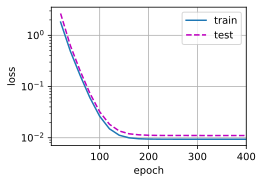

In [11]:
train(poly_features[:n_train, :4], poly_features[n_train:, :4],
      labels[:n_train], labels[n_train:])

weight: [[3.5033476 4.0833497]]


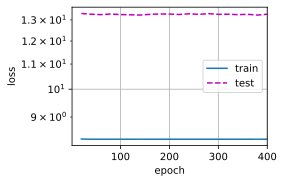

In [13]:
train(poly_features[:n_train, :2], poly_features[n_train:, :2],
      labels[:n_train], labels[n_train:])

weight: [[ 4.942206    1.3560051  -3.1034994   4.860323   -0.7857955   1.7364477
   0.16155794  0.41151854  0.20479968  0.03424105  0.01703467  0.08445643
  -0.03281931 -0.16728957 -0.15637268 -0.14822365  0.15119097  0.06630047
   0.10527375  0.05141792]]


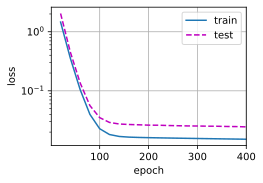

In [14]:
train(poly_features[:n_train, :], poly_features[n_train:, :],
      labels[:n_train], labels[n_train:])